# Create 256x256 crop dataset (fixed coordinate), and save them

In [1]:
import os
import numpy as np
import pandas as pd
import skimage
from tqdm import tqdm

## Training Data

In [ ]:
path = '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/train/'
save_folder = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/train/'
files = os.listdir(path)
files = [file for file in files if file.endswith('.phenotype.tif')]
files = [file for file in files if not file.startswith('.')]
print(len(files))

PS = 256
for i in tqdm(range(len(files))):
    im = skimage.io.imread(path + files[i])
    gt = skimage.io.imread(path + files[i].replace('.phenotype.tif', '.phenotype_outlines.png'))

    H,W = im.shape
    patches_per_image = (W // PS) * (H // PS)
    X = np.linspace(0, W - W % PS, W // PS + 1)
    Y = np.linspace(0, H - H % PS, H // PS + 1)
    X,Y = np.meshgrid(X[:-1],Y[:-1], indexing='ij')
    X = X.reshape((patches_per_image,))
    Y = Y.reshape((patches_per_image,))
    C = np.stack((Y,X)).T
    
    idx = 0
    for j in range(len(C)):
        r,c = C[j]
        r,c = int(r), int(c)
        # check if gt patch has micronuclei or not
        gt_patch = gt[r:r+PS, c:c+PS]
        gt_labels = skimage.morphology.label(gt_patch)
        if np.max(gt_labels) > 0: # 1 represents only background
            # save the corresponding input and gt
            im_patch = im[r:r+PS, c:c+PS]
            
            # reconstruct filename
            imid = files[i].split('.')[0]
            suffix = f'.crop{idx}'
            new_imid = imid + suffix
            skimage.io.imsave(save_folder + new_imid + '.phenotype.tif', im_patch)
            skimage.io.imsave(save_folder + new_imid + '.phenotype_outlines.png', gt_labels.astype(np.uint16))
            idx = idx + 1

## Validation Data

In [ ]:
path = '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation/'
save_folder = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/validation/'
files = os.listdir(path)
files = [file for file in files if file.endswith('.phenotype.tif')]
files = [file for file in files if not file.startswith('.')]
print(len(files))

PS = 256
for i in tqdm(range(len(files))):
    im = skimage.io.imread(path + files[i])
    gt = skimage.io.imread(path + files[i].replace('.phenotype.tif', '.phenotype_outlines.png'))

    H,W = im.shape
    patches_per_image = (W // PS) * (H // PS)
    X = np.linspace(0, W - W % PS, W // PS + 1)
    Y = np.linspace(0, H - H % PS, H // PS + 1)
    X,Y = np.meshgrid(X[:-1],Y[:-1], indexing='ij')
    X = X.reshape((patches_per_image,))
    Y = Y.reshape((patches_per_image,))
    C = np.stack((Y,X)).T
    for j in range(len(C)):
        r,c = C[j]
        r,c = int(r), int(c)
        # check if gt patch has micronuclei or not
        gt_patch = gt[r:r+PS, c:c+PS]
        gt_labels = skimage.morphology.label(gt_patch)
        
        idx = 0
        if np.max(gt_labels) > 0: # 1 represents only background
            # save the corresponding input and gt
            im_patch = im[r:r+PS, c:c+PS]
            
            # reconstruct filename
            imid = files[i].split('.')[0]
            suffix = f'.crop{idx}'
            new_imid = imid + suffix
            
            skimage.io.imsave(save_folder + new_imid + '.phenotype.tif', im_patch)
            skimage.io.imsave(save_folder + new_imid + '.phenotype_outlines.png', gt_labels.astype(np.uint16))
            idx = idx + 1

In [ ]:
save_folder = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/train/'
files = os.listdir(save_folder)
files = [file for file in files if file.endswith('.phenotype_outlines.png')]
files = [file for file in files if not file.startswith('.')]

for i in range(len(files)):
    crop = skimage.io.imread(save_folder + files[i])
    labels = skimage.morphology.label(crop)
    if len(np.unique(labels)) == 1:
        print('Empty GT crop found!')

In [ ]:
save_folder = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/validation/'
files = os.listdir(save_folder)
files = [file for file in files if file.endswith('.phenotype_outlines.png')]
files = [file for file in files if not file.startswith('.')]

for i in range(len(files)):
    crop = skimage.io.imread(save_folder + files[i])
    labels = skimage.morphology.label(crop)
    if len(np.unique(labels)) == 1:
        print('Empty GT crop found!')

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from glob import glob
from IPython.display import FileLink
from typing import Union, Tuple, Optional

import numpy as np
import imageio.v3 as imageio
from matplotlib import pyplot as plt
from skimage.measure import label as connected_components

import torch

from torch_em.util.debug import check_loader
from torch_em.data import MinInstanceSampler
from torch_em.util.util import get_random_colors

import micro_sam.training as sam_training
from micro_sam.sample_data import fetch_tracking_example_data, fetch_tracking_segmentation_data
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation

2025-05-12 08:02:57.351543: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-12 08:02:57.405337: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-12 08:02:58.291417: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


- Leave ROI argument as None to use all data under the path

In [ ]:
batch_size = 1  # the training batch size
patch_shape = (256, 256)  # the size of patches for training
sampler = MinInstanceSampler(min_size=25)

In [ ]:
raw_key, label_key = '*.phenotype.tif', '*.phenotype_outlines.png'
train_dir = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/train/'
val_dir = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/validation/'
train_instance_segmentation = True
train_segmentation_dir = train_dir
val_segmentation_dir = val_dir

In [ ]:
train_loader = sam_training.default_sam_loader(
    raw_paths=train_dir,
    raw_key=raw_key,
    label_paths=train_segmentation_dir,
    label_key=label_key,
    with_segmentation_decoder=train_instance_segmentation,
    patch_shape=patch_shape,
    batch_size=batch_size,
    is_seg_dataset=True,
    rois=None,
    shuffle=True,
    raw_transform=sam_training.identity,
    sampler=sampler
)

val_loader = sam_training.default_sam_loader(
    raw_paths=val_dir,
    raw_key=raw_key,
    label_paths=val_segmentation_dir,
    label_key=label_key,
    with_segmentation_decoder=train_instance_segmentation,
    patch_shape=patch_shape,
    batch_size=batch_size,
    is_seg_dataset=True,
    rois=None,
    shuffle=True,
    raw_transform=sam_training.identity,
    sampler=sampler
)

In [4]:
n_objects_per_batch = 5  # the number of objects per batch that will be sampled
device = "cuda" if torch.cuda.is_available() else "cpu"  # the device/GPU used for training
n_epochs = 5  # how long we train (in epochs)

# The model_type determines which base model is used to initialize the weights that are finetuned.
# We use vit_b here because it can be trained faster. Note that vit_h usually yields higher quality results.
model_type = "vit_b_lm"

# The name of the checkpoint. The checkpoints will be stored in './checkpoints/<checkpoint_name>'
checkpoint_name = "sam_hela"

root_dir = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data'

## Use tmux to run on workstation

In [ ]:
sam_training.train_sam(
    name=checkpoint_name,
    save_root=os.path.join(root_dir, "models"),
    model_type=model_type,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=n_epochs,
    n_objects_per_batch=n_objects_per_batch,
    with_segmentation_decoder=train_instance_segmentation,
    device=device
)

# Load trained model to make predictions

In [7]:
checkpoint_name = "sam_hela"
best_checkpoint = os.path.join(os.getcwd(), 'microSAM_finetune_data', "models", "checkpoints", checkpoint_name, "best.pt")
print(best_checkpoint)

/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/models/checkpoints/sam_hela/best.pt


## Run automatic instance segmentation

In [8]:
def run_automatic_instance_segmentation(
    image: np.ndarray,
    checkpoint_path: Union[os.PathLike ,str],
    model_type: str = "vit_b_lm",
    device: Optional[Union[str, torch.device]] = None,
    tile_shape: Optional[Tuple[int, int]] = None,
    halo: Optional[Tuple[int, int]] = None,
):
    """Automatic Instance Segmentation (AIS) by training an additional instance decoder in SAM.

    NOTE: AIS is supported only for `µsam` models.

    Args:
        image: The input image.
        checkpoint_path: The path to stored checkpoints.
        model_type: The choice of the `µsam` model.
        device: The device to run the model inference.
        tile_shape: The tile shape for tiling-based segmentation.
        halo: The overlap shape on each side per tile for stitching the segmented tiles.

    Returns:
        The instance segmentation.
    """
    # Step 1: Get the 'predictor' and 'segmenter' to perform automatic instance segmentation.
    predictor, segmenter = get_predictor_and_segmenter(
        model_type=model_type,  # choice of the Segment Anything model
        checkpoint=checkpoint_path,  # overwrite to pass your own finetuned model.
        device=device,  # the device to run the model inference.
        is_tiled=(tile_shape is not None),  # whether to run automatic segmentation.
    )

    # Step 2: Get the instance segmentation for the given image.
    prediction = automatic_instance_segmentation(
        predictor=predictor,  # the predictor for the Segment Anything model.
        segmenter=segmenter,  # the segmenter class responsible for generating predictions.
        input_path=image,  # the filepath to image or the input array for automatic segmentation.
        ndim=2,  # the number of input dimensions.
        tile_shape=tile_shape,  # the tile shape for tiling-based prediction.
        halo=halo,  # the overlap shape for tiling-based prediction.
    )

    return prediction

In [14]:
im = skimage.io.imread(os.path.join(os.getcwd(), 'all_data_micronuclei_no_rescale/validation/C1-20X_c0_B3_Tile-24.phenotype.tif'))
gt = skimage.io.imread(os.path.join(os.getcwd(), 'all_data_micronuclei_no_rescale/validation/C1-20X_c0_B3_Tile-24.phenotype_outlines.png'))
print(im.shape)

(2720, 2720)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # the device/GPU used for training
model_type = "vit_b_lm"

prediction = run_automatic_instance_segmentation(
    image=im,
    checkpoint_path=best_checkpoint,
    model_type=model_type,
    device=device
)

Initialize instance segmentation with decoder: 100%|██████████| 1/1 [00:00<00:00, 20.32it/s]


In [26]:
np.unique(prediction)

array([   0,    1,    2, ..., 2015, 2016, 2017], dtype=int32)

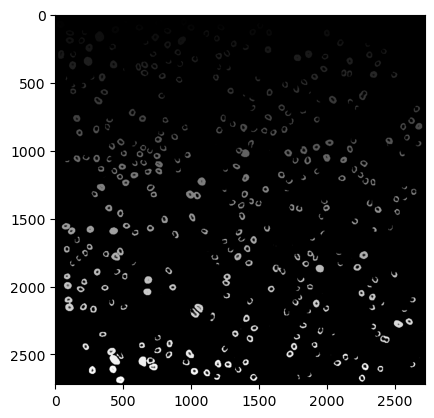

In [27]:
plt.imshow(prediction, cmap='gray')

In [28]:
MICRON_AREA_THRESHOLD = 100

labels = skimage.morphology.label(prediction)
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD:
        micron_labels.append(i)
        
micro_mask = np.zeros_like(prediction)
for i in micron_labels:
    micro_mask += (labels == i)

In [29]:
np.unique(micro_mask)

array([0, 1], dtype=int32)

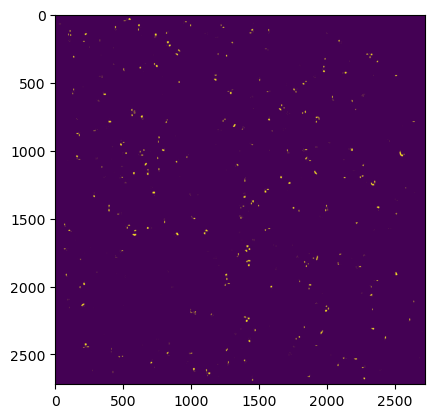

In [30]:
plt.imshow(micro_mask)

In [ ]:
from IPython.display import clear_output

NameError: name 'clear_output' is not defined

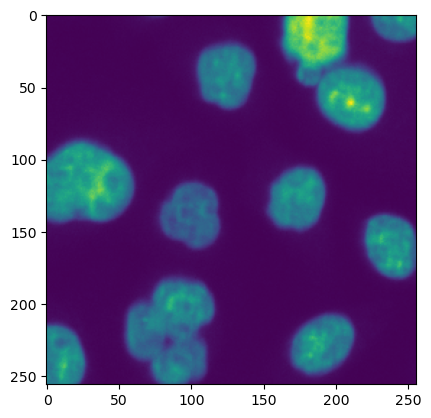

In [ ]:
save_folder = '/scr/yren/micronuclei-detection/baselines/microSAM_finetune_data/train/'
files = os.listdir(save_folder)
files = [file for file in files if file.endswith('.phenotype.tif')]
files = [file for file in files if not file.startswith('.')]

for i in range(len(files)):
    im = skimage.io.imread(save_folder + files[i])
    plt.imshow(im)
    
    plt.show()
    plt.close('all')
    clear_output(wait=True)